# C-MAPS FD001 — Exploratory Data Analysis

Sensor variance analysis and degradation pattern exploration for the FD001 turbofan dataset.

In [23]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_data  

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load Data

In [24]:
train_df, test_df, test_rul = load_data('../data/')

print(f"Training set: {train_df.shape}")
print(f"Test set: {test_df.shape}")
print(f"True RUL values: {test_rul.shape}")

loaded training data: 20631 records from 100 engines
calculated RUL: min=0, max=125, mean=86.8
loaded test data: 13096 records from 100 engines
loaded ground truth RUL: min=7, max=125, mean=74.5
Training set: (20631, 27)
Test set: (13096, 26)
True RUL values: (100, 1)


## 2. Data Overview

In [25]:
train_df.head()

,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [26]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_id       20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-null  float64

## 3. RUL Distribution

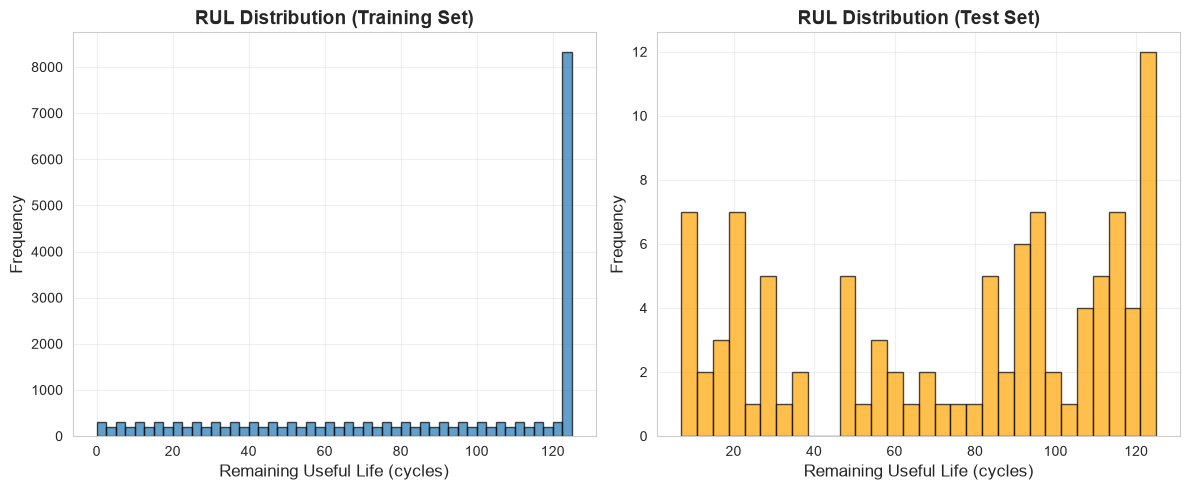

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Remaining Useful Life (cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('RUL Distribution (Training Set)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(test_rul['RUL'], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Remaining Useful Life (cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('RUL Distribution (Test Set)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Engine Lifecycle Analysis

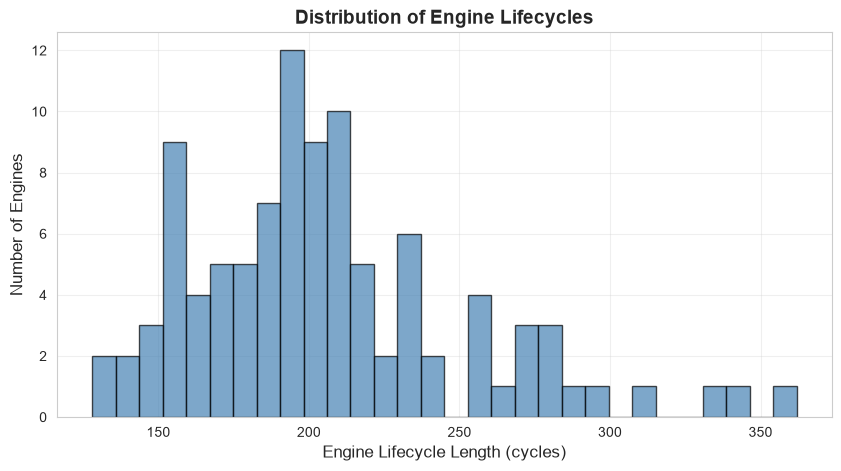

Average lifecycle: 206.3 cycles
Min lifecycle: 128 cycles
Max lifecycle: 362 cycles


In [28]:
# Lifecycle length distribution
lifecycle_lengths = train_df.groupby('unit_id')['cycle'].max()

plt.figure(figsize=(10, 5))
plt.hist(lifecycle_lengths, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Engine Lifecycle Length (cycles)', fontsize=12)
plt.ylabel('Number of Engines', fontsize=12)
plt.title('Distribution of Engine Lifecycles', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average lifecycle: {lifecycle_lengths.mean():.1f} cycles")
print(f"Min lifecycle: {lifecycle_lengths.min()} cycles")
print(f"Max lifecycle: {lifecycle_lengths.max()} cycles")

## 5. Sample Engine Degradation

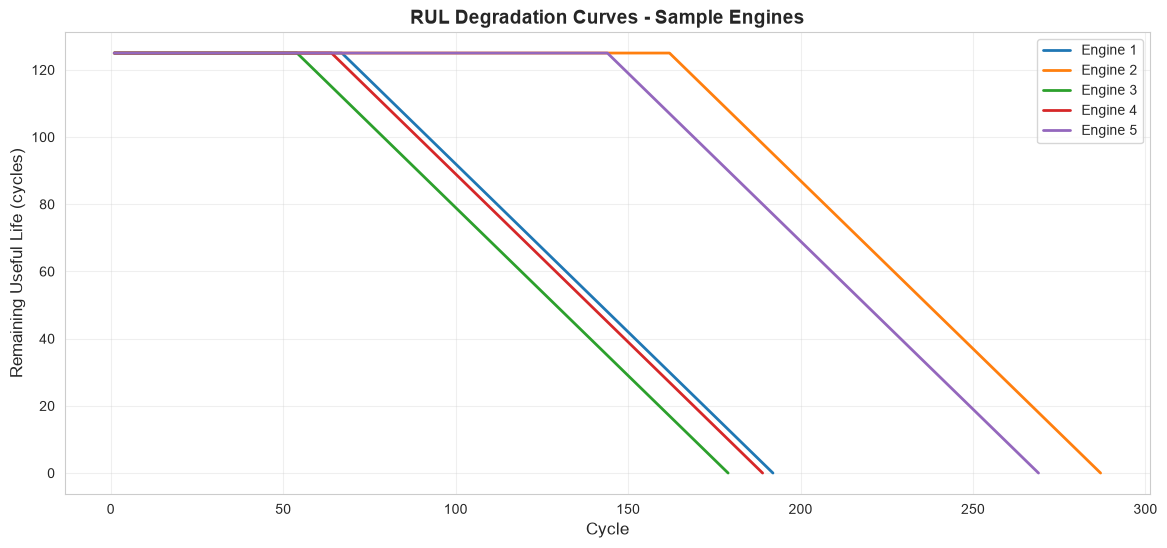

In [29]:
# Plot RUL degradation for first 5 engines
plt.figure(figsize=(14, 6))

for engine_id in range(1, 6):
    engine_data = train_df[train_df['unit_id'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['RUL'], label=f'Engine {engine_id}', linewidth=2)

plt.xlabel('Cycle', fontsize=12)
plt.ylabel('Remaining Useful Life (cycles)', fontsize=12)
plt.title('RUL Degradation Curves - Sample Engines', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Sensor Correlation Analysis

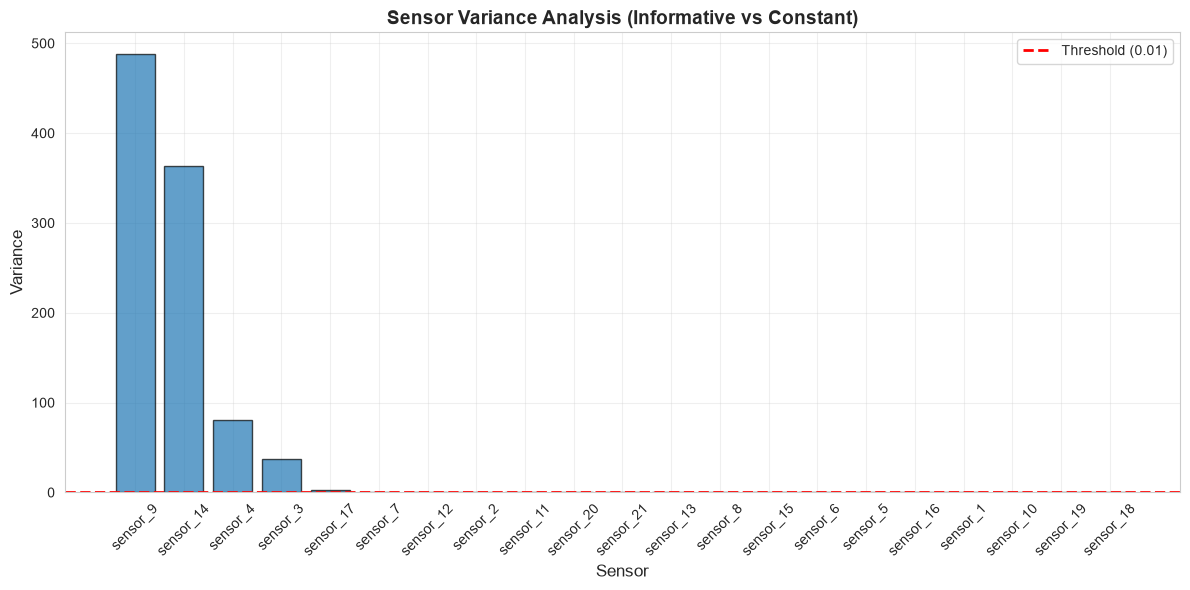


Sensors with variance > 0.01: 11
Sensors with variance <= 0.01: 10


In [30]:
# Calculate sensor variances
sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]
sensor_variances = train_df[sensor_cols].var().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(sensor_variances)), sensor_variances.values, edgecolor='black', alpha=0.7)
plt.xticks(range(len(sensor_variances)), sensor_variances.index, rotation=45)
plt.xlabel('Sensor', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.title('Sensor Variance Analysis (Informative vs Constant)', fontsize=14, fontweight='bold')
plt.axhline(y=0.01, color='red', linestyle='--', linewidth=2, label='Threshold (0.01)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSensors with variance > 0.01: {(sensor_variances > 0.01).sum()}")
print(f"Sensors with variance <= 0.01: {(sensor_variances <= 0.01).sum()}")

## Summary

Key Insights:

- 100 training engines with varying lifecycles (128-362 cycles)
- RUL capped at 125 cycles (standard practice in prognostics)
- 10 sensors removed — near-zero variance, constant on FD001
- 11 informative sensors retained for feature engineering
- Rolling window features capture temporal degradation patterns
- Data pipeline validated and ready for XGBoost training